<a href="https://colab.research.google.com/github/raymingchen/ODE/blob/main/2ndODEproblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grid: 7 points, min spacing: 4.68e-01


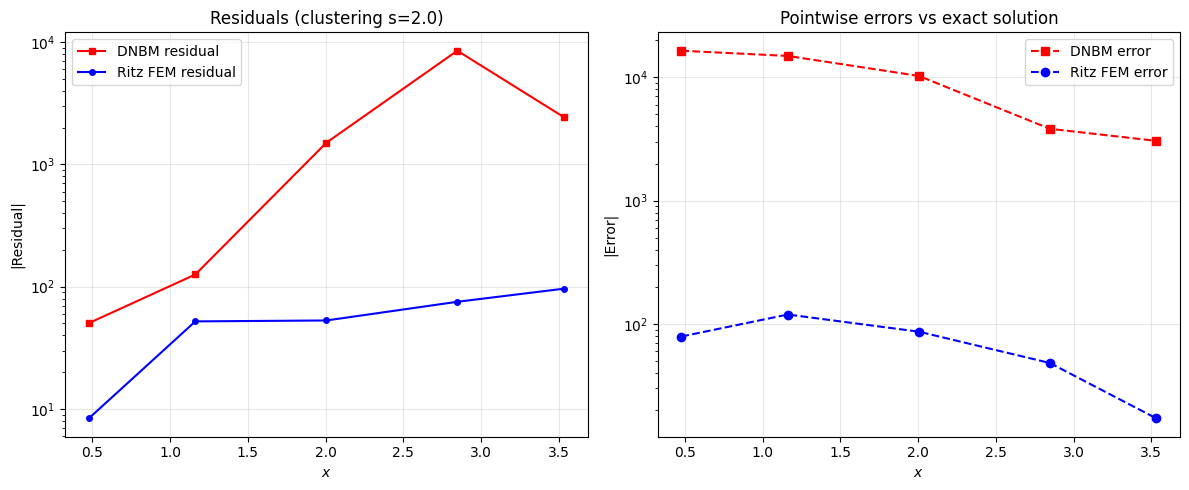


=== Summary ===
DNBM   max residual (interior) = 8.5202e+03
Ritz   max residual (interior) = 9.6298e+01
DNBM   max error (interior)    = 1.6447e+04
Ritz   max error (interior)    = 1.1933e+02
DNBM   L2 error = 3.7430e+03
Ritz   L2 error = 1.5254e+02


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss

# ------------------------------------------------------------
# 1. Problem definition (exact solution on [0.01,4])
# ------------------------------------------------------------
alpha, beta = 0.01, 4.0
y0, yN = 2.0, 5.0

def y_exact(x):
    return x + np.exp(x) * np.sin(np.pi * x)

def y_exact_d1(x):
    return 1 + np.exp(x)*(np.sin(np.pi*x) + np.pi*np.cos(np.pi*x))

def y_exact_d2(x):
    return np.exp(x)*(2*np.pi*np.cos(np.pi*x) + (1 - np.pi**2)*np.sin(np.pi*x))

# ODE coefficients
def A(x):   return 1.0 + x**2
def B(x):   return np.sin(x) + x
def C(x):   return 2.0 + np.cos(2*np.pi*x)

# Right-hand side (derived from exact solution)
def f(x):
    ex = np.exp(x)
    sin_pi = np.sin(np.pi*x)
    cos_pi = np.cos(np.pi*x)
    term1 = (1 + x**2) * ex * (2*np.pi*cos_pi + (1 - np.pi**2)*sin_pi)
    term2 = (np.sin(x) + x) * (1 + ex*(sin_pi + np.pi*cos_pi))
    term3 = (2 + np.cos(2*np.pi*x)) * (x + ex*sin_pi)
    return term1 + term2 + term3

# Needed for weak form: A'(x)
def dA(x): return 2.0*x

# ------------------------------------------------------------
# 2. Grid with clustering strength = 2
# ------------------------------------------------------------
Npoints = 7                    # including boundaries
clustering_strength = 2.0

t = np.linspace(0, 1, Npoints)
if clustering_strength == 0:
    x = alpha + (beta - alpha) * t
else:
    s = clustering_strength
    x = alpha + (beta - alpha) * (np.tanh(s*(t - 0.5)) / np.tanh(s/2) + 1.0) / 2.0
x[0]  = alpha
x[-1] = beta
n = len(x)
print(f"Grid: {n} points, min spacing: {np.min(np.diff(x)):.2e}")

# ------------------------------------------------------------
# 3. Quadrature (Gauss–Legendre)
# ------------------------------------------------------------
nq = 64
xq, wq = leggauss(nq)
xq = 0.5*(beta - alpha)*xq + 0.5*(alpha + beta)
wq = 0.5*(beta - alpha)*wq

def integrate(integrand):
    return np.sum(wq * integrand(xq))

# ------------------------------------------------------------
# 4. DNBM basis (polynomial coefficients)
# ------------------------------------------------------------
D = np.array([[(xi - xj)**4 for xj in x] for xi in x])
D_inv = np.linalg.pinv(D, rcond=1e-8)

alpha_coeff = np.zeros((n, 5))   # φ_i
beta_coeff  = np.zeros((n, 4))   # φ_i'
gamma_coeff = np.zeros((n, 3))   # φ_i''

for i in range(n):
    for j in range(n):
        xj = x[j]
        poly4 = np.array([xj**4, -4*xj**3, 6*xj**2, -4*xj, 1.0])
        poly3 = np.array([-4*xj**3, 12*xj**2, -12*xj, 4.0])
        poly2 = np.array([12*xj**2, -24*xj, 12.0])
        alpha_coeff[i] += D_inv[i, j] * poly4
        beta_coeff[i]  += D_inv[i, j] * poly3
        gamma_coeff[i] += D_inv[i, j] * poly2

def polyval(coeff, xv):
    return np.polyval(coeff[::-1], xv)

# ------------------------------------------------------------
# 5. DNBM system (Galerkin with quadrature)
# ------------------------------------------------------------
N = n - 2
R_mat = np.zeros((N, N))
Q_vec = np.zeros(N)

for i in range(1, n-1):
    ii = i - 1
    for j in range(1, n-1):
        jj = j - 1
        def integrand_ij(xv):
            bi = polyval(beta_coeff[i], xv)
            bj = polyval(beta_coeff[j], xv)
            ai = polyval(alpha_coeff[i], xv)
            aj = polyval(alpha_coeff[j], xv)
            return A(xv)*bi*bj + (dA(xv)-B(xv))*bi*aj - C(xv)*ai*aj
        R_mat[ii, jj] = integrate(integrand_ij)

    def integrand_rhs(xv):
        return -f(xv) * polyval(alpha_coeff[i], xv)
    Q_vec[ii] = integrate(integrand_rhs)

# Boundary contributions
for i in range(1, n-1):
    ii = i - 1
    def integrand_i0(xv):
        bi = polyval(beta_coeff[i], xv)
        b0 = polyval(beta_coeff[0], xv)
        ai = polyval(alpha_coeff[i], xv)
        a0 = polyval(alpha_coeff[0], xv)
        return A(xv)*bi*b0 + (dA(xv)-B(xv))*bi*a0 - C(xv)*ai*a0
    Q_vec[ii] -= y0 * integrate(integrand_i0)

    def integrand_iN(xv):
        bi = polyval(beta_coeff[i], xv)
        bN = polyval(beta_coeff[n-1], xv)
        ai = polyval(alpha_coeff[i], xv)
        aN = polyval(alpha_coeff[n-1], xv)
        return A(xv)*bi*bN + (dA(xv)-B(xv))*bi*aN - C(xv)*ai*aN
    Q_vec[ii] -= yN * integrate(integrand_iN)

reg = 1e-12 * np.eye(N)
y_int = np.linalg.solve(R_mat + reg, Q_vec)

y_dnbm = np.zeros(n)
y_dnbm[0] = y0
y_dnbm[-1] = yN
y_dnbm[1:-1] = y_int

# ------------------------------------------------------------
# 6. Ritz FEM (global polynomial basis)
# ------------------------------------------------------------
M_ritz = 12
yL_coeff = np.array([0.0, 1.0])   # yL(x)=x satisfies BCs

phi_coeff = []
dphi_coeff = []
for k in range(M_ritz):
    coeff = np.zeros(k+3)
    coeff[k]   = alpha * beta
    coeff[k+1] = -(alpha + beta)
    coeff[k+2] = 1.0
    phi_coeff.append(coeff)
    dcoeff = np.zeros(k+2)
    if k >= 1:
        dcoeff[k-1] = k * alpha * beta
    dcoeff[k] = -(k+1) * (alpha + beta)
    dcoeff[k+1] = (k+2)
    dphi_coeff.append(dcoeff)

A_ritz = np.zeros((M_ritz, M_ritz))
F_ritz = np.zeros(M_ritz)

for i in range(M_ritz):
    for j in range(M_ritz):
        def integrand_Aij(xv):
            dpi = polyval(dphi_coeff[i], xv)
            dpj = polyval(dphi_coeff[j], xv)
            pi = polyval(phi_coeff[i], xv)
            pj = polyval(phi_coeff[j], xv)
            return A(xv)*dpi*dpj + (dA(xv)-B(xv))*dpi*pj - C(xv)*pi*pj
        A_ritz[i,j] = integrate(integrand_Aij)

    def integrand_f(xv):
        return -f(xv) * polyval(phi_coeff[i], xv)
    F_ritz[i] = integrate(integrand_f)

    def integrand_yL(xv):
        yL = xv
        yLp = 1.0
        dpi = polyval(dphi_coeff[i], xv)
        pi = polyval(phi_coeff[i], xv)
        return A(xv)*yLp*dpi + (dA(xv)-B(xv))*yLp*pi - C(xv)*yL*pi
    F_ritz[i] -= integrate(integrand_yL)

c_ritz = np.linalg.solve(A_ritz, F_ritz)

y_ritz_coeff = np.array(yL_coeff)
for k in range(M_ritz):
    if len(y_ritz_coeff) < len(phi_coeff[k]):
        y_ritz_coeff = np.pad(y_ritz_coeff, (0, len(phi_coeff[k]) - len(y_ritz_coeff)))
    y_ritz_coeff[:len(phi_coeff[k])] += c_ritz[k] * phi_coeff[k]

y_ritz = np.polyval(y_ritz_coeff[::-1], x)
y_exact_vals = y_exact(x)

# ------------------------------------------------------------
# 7. Residuals (exact ODE residual at grid points)
# ------------------------------------------------------------
def compute_residual_dnbm(x_grid, y_vals):
    R = np.full(len(x_grid), np.nan)
    for k in range(1, len(x_grid)-1):
        xk = x_grid[k]
        y_val = 0.0; yp_val = 0.0; ypp_val = 0.0
        for i in range(len(x_grid)):
            y_val += y_vals[i] * np.polyval(alpha_coeff[i][::-1], xk)
            yp_val += y_vals[i] * np.polyval(beta_coeff[i][::-1], xk)
            ypp_val += y_vals[i] * np.polyval(gamma_coeff[i][::-1], xk)
        R[k] = A(xk)*ypp_val + B(xk)*yp_val + C(xk)*y_val - f(xk)
    return R

def compute_residual_ritz(x_grid, y_coeff):
    y_der1 = np.polyder(y_coeff[::-1])
    y_der2 = np.polyder(y_der1)
    R = np.full(len(x_grid), np.nan)
    for k in range(1, len(x_grid)-1):
        xk = x_grid[k]
        y_val = np.polyval(y_coeff[::-1], xk)
        yp_val = np.polyval(y_der1, xk)
        ypp_val = np.polyval(y_der2, xk)
        R[k] = A(xk)*ypp_val + B(xk)*yp_val + C(xk)*y_val - f(xk)
    return R

res_dnbm = compute_residual_dnbm(x, y_dnbm)
res_ritz = compute_residual_ritz(x, y_ritz_coeff)

# ------------------------------------------------------------
# 8. Errors vs exact solution
# ------------------------------------------------------------
err_dnbm = np.abs(y_dnbm - y_exact_vals)
err_ritz = np.abs(y_ritz - y_exact_vals)

# ------------------------------------------------------------
# 9. Plotting
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.semilogy(x[1:-1], np.abs(res_dnbm[1:-1]), 'r-s', markersize=4, label='DNBM residual')
plt.semilogy(x[1:-1], np.abs(res_ritz[1:-1]), 'b-o', markersize=4, label='Ritz FEM residual')
plt.xlabel('$x$')
plt.ylabel('|Residual|')
plt.title(f'Residuals (clustering s={clustering_strength})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.semilogy(x[1:-1], err_dnbm[1:-1], 'r--s', label='DNBM error')
plt.semilogy(x[1:-1], err_ritz[1:-1], 'b--o', label='Ritz FEM error')
plt.xlabel('$x$')
plt.ylabel('|Error|')
plt.title('Pointwise errors vs exact solution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('DNBM_vs_RitzFEM_newODE.pdf', dpi=300)
plt.show()

# ------------------------------------------------------------
# 10. Summary
# ------------------------------------------------------------
print("\n=== Summary ===")
print(f"DNBM   max residual (interior) = {np.nanmax(np.abs(res_dnbm[1:-1])):.4e}")
print(f"Ritz   max residual (interior) = {np.nanmax(np.abs(res_ritz[1:-1])):.4e}")
print(f"DNBM   max error (interior)    = {np.nanmax(err_dnbm[1:-1]):.4e}")
print(f"Ritz   max error (interior)    = {np.nanmax(err_ritz[1:-1]):.4e}")
# L2 error computed on quadrature points
y_exact_q = y_exact(xq)
# DNBM: we need to evaluate the DNBM solution at quadrature points; we can interpolate using the basis
y_dnbm_q = np.zeros_like(xq)
for i in range(n):
    y_dnbm_q += y_dnbm[i] * np.polyval(alpha_coeff[i][::-1], xq)
errL2_dnbm = np.sqrt(np.sum(wq * (y_dnbm_q - y_exact_q)**2))
errL2_ritz = np.sqrt(np.sum(wq * (np.polyval(y_ritz_coeff[::-1], xq) - y_exact_q)**2))
print(f"DNBM   L2 error = {errL2_dnbm:.4e}")
print(f"Ritz   L2 error = {errL2_ritz:.4e}")